In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data (ensure the CSV file path is correct)
df = pd.read_csv('/content/insurance.csv')
df.head()

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01


In [3]:
# Check for missing values and drop them
print(f"Missing values before: {df.isna().sum().sum()}")
df.dropna(inplace=True)

# Remove duplicates if any
df.drop_duplicates(inplace=True)

Missing values before: 8


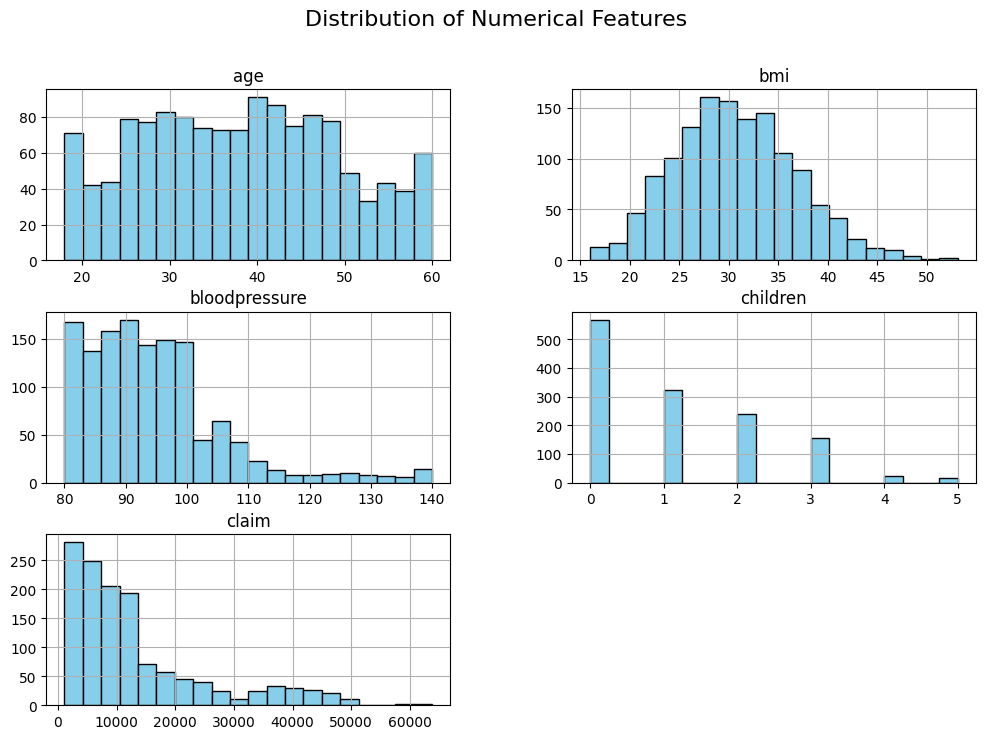

In [4]:
# Numerical feature distribution
numeric_cols = ['age', 'bmi', 'bloodpressure', 'children', 'claim']
df[numeric_cols].hist(bins=20, figsize=(12, 8), color='skyblue', edgecolor='black')
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib

# Define features and target
X = df[['age', 'gender', 'bmi', 'bloodpressure', 'diabetic', 'children', 'smoker']]
y = df['claim']

# Encoding categorical columns
cat_cols = ['gender', 'diabetic', 'smoker']
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    joblib.dump(le, f'label_encoder_{col}.pickle')

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling numerical features
num_cols = ['age', 'bmi', 'bloodpressure', 'children']
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])
joblib.dump(scaler, 'scalar.pickle')

/tmp/ipykernel_1362/4240682171.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
/tmp/ipykernel_1362/4240682171.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
/tmp/ipykernel_1362/4240682171.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_g

['scalar.pickle']

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Training Random Forest as it was the best performing model in the video
rf = RandomForestRegressor()
params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(rf, params, cv=3, scoring='r2')
grid_rf.fit(X_train, y_train)

best_model = grid_rf.best_estimator_
joblib.dump(best_model, 'best_model.pickle')
print(f"Model R² Score: {best_model.score(X_test, y_test)}")

Model R² Score: 0.817083191319742
